In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

cp: cannot stat 'kaggle.json': No such file or directory


In [1]:
!kaggle datasets download -d gpiosenka/cards-image-datasetclassification

Dataset URL: https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification
License(s): CC0-1.0
100% 385M/385M [00:19<00:00, 20.6MB/s]



In [3]:
import zipfile
zip_ref = zipfile.ZipFile('/content/cards-image-datasetclassification.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

#Check the data of Test and Train folder


In [4]:
train = '/content/cards/train'
test = '/content/cards/test'

In [5]:
import os

print("Contents of /content:")
print(os.listdir('/content'))

Contents of /content:
['.config', 'test', '14card types-14-(200 X 200)-94.61.h5', 'cards.csv', 'valid', '53cards-53-(200 X 200)-100.00.h5', 'train', 'cards-image-datasetclassification.zip', 'sample_data']


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense,Conv2D, MaxPooling2D,Flatten

In [9]:
# generators
train_ds =  keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)

test_ds =  keras.utils.image_dataset_from_directory(
    directory='/content/test',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)


Found 7624 files belonging to 53 classes.
Found 265 files belonging to 53 classes.


In [10]:
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/valid',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256,256)
)


Found 265 files belonging to 53 classes.


In [11]:
# We have 53 classes. How can i see that which vlass is assinged ehich integer ?
for i, class_name in enumerate(train_ds.class_names):
    print(f"Integer: {i}, Class Name: {class_name}")

Integer: 0, Class Name: ace of clubs
Integer: 1, Class Name: ace of diamonds
Integer: 2, Class Name: ace of hearts
Integer: 3, Class Name: ace of spades
Integer: 4, Class Name: eight of clubs
Integer: 5, Class Name: eight of diamonds
Integer: 6, Class Name: eight of hearts
Integer: 7, Class Name: eight of spades
Integer: 8, Class Name: five of clubs
Integer: 9, Class Name: five of diamonds
Integer: 10, Class Name: five of hearts
Integer: 11, Class Name: five of spades
Integer: 12, Class Name: four of clubs
Integer: 13, Class Name: four of diamonds
Integer: 14, Class Name: four of hearts
Integer: 15, Class Name: four of spades
Integer: 16, Class Name: jack of clubs
Integer: 17, Class Name: jack of diamonds
Integer: 18, Class Name: jack of hearts
Integer: 19, Class Name: jack of spades
Integer: 20, Class Name: joker
Integer: 21, Class Name: king of clubs
Integer: 22, Class Name: king of diamonds
Integer: 23, Class Name: king of hearts
Integer: 24, Class Name: king of spades
Integer: 25, 

In [12]:
# Normalize Data
def process(image,label):
  image = tf.cast(image/255. ,tf.float32)
  return image,label

train_ds = train_ds.map(process)
test_ds = test_ds.map(process)
validation_ds = validation_ds.map(process)

#Making our own model....(By involving our architecture)

In [13]:
# Making Our Model
model = Sequential()

model.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D(pool_size=(2,2),strides =2 ,padding='valid'))
model.add(Conv2D(64,kernel_size=(6,6),padding='valid',activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2),strides =2 ,padding='valid'))

model.add(Flatten())

model.add(Dense(64,activation='relu'))
model.add(Dense(32,activation='relu'))
model.add(Dense(53,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [14]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [15]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 122, 122, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 238144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    15,241,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 53)             │         1,749 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,319,797 (58.44 MB)

 Trainable params: 15,319,797 (58.44 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
history = model.fit(train_ds,epochs = 5,validation_data=validation_ds)

Epoch 1/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 36s 94ms/step - accuracy: 0.2486 - loss: 3.1035 - val_accuracy: 0.5019 - val_loss: 1.7404
Epoch 2/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.5283 - loss: 1.8071 - val_accuracy: 0.6302 - val_loss: 1.4442
Epoch 3/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 64ms/step - accuracy: 0.6872 - loss: 1.1322 - val_accuracy: 0.6415 - val_loss: 1.3674
Epoch 4/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.7893 - loss: 0.6684 - val_accuracy: 0.6302 - val_loss: 1.6140
Epoch 5/5
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 65ms/step - accuracy: 0.8221 - loss: 0.4218 - val_accuracy: 0.5321 - val_loss: 2.1224


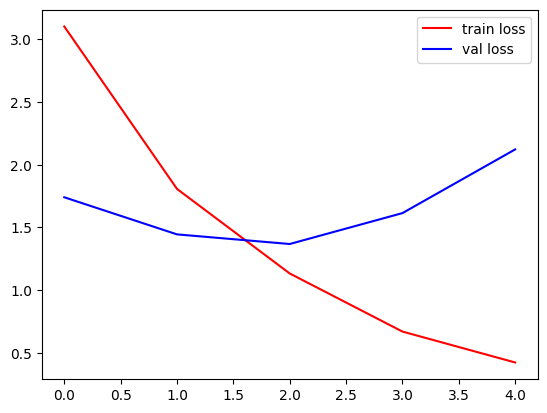

In [17]:
# By looking at this code we can say that this is a case of overfitting
import matplotlib.pyplot as plt

plt.plot(history.history['loss'],color='red',label='train loss')
plt.plot(history.history['val_loss'],color='blue',label='val loss')
plt.legend()
plt.show()

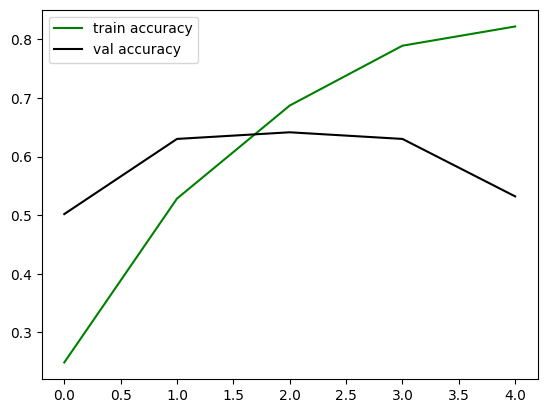

In [18]:
plt.plot(history.history['accuracy'],color='green')
plt.plot(history.history['val_accuracy'],color='black')
plt.legend(['train accuracy','val accuracy'])
plt.show ()

In [19]:
# Now check for the test data
pred = model.predict(test_ds)

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 60ms/step


In [20]:
from sklearn.metrics import f1_score,accuracy_score,confusion_matrix
import numpy as np

In [21]:
# Extract true labels from test_ds
y_true = []
for _, labels in test_ds:
    y_true.extend(labels.numpy())
y_true = np.array(y_true)

# Convert predictions (probabilities) to class labels
y_pred = np.argmax(pred, axis=1)

f1 = f1_score(y_true, y_pred, average='weighted') # Use 'weighted' for multi-class classification
print(f"F1 Score: {f1:.4f}")

accuracy = accuracy_score(y_true, y_pred)
print(f"Accuracy Score: {accuracy:.4f}")

F1 Score: 0.0175
Accuracy Score: 0.0226


# Now i have gone through the raw CNN architecture with only 10 epochs ... lets see with BatchNormalization and Dropout Layers with more epochs.

In [22]:
from keras.layers import BatchNormalization,Dropout

In [23]:
model_adv = Sequential()

model_adv.add(Conv2D(32,kernel_size=(3,3),padding='valid',activation='relu',input_shape=(256,256,3)))
model_adv.add(MaxPooling2D(pool_size=(2,2),strides =2 ,padding='valid'))
model_adv.add(BatchNormalization())

model_adv.add(Conv2D(64,kernel_size=(6,6),padding='valid',activation='relu'))
model_adv.add(MaxPooling2D(pool_size=(2,2),strides =2 ,padding='valid'))
model_adv.add(BatchNormalization())

model_adv.add(Flatten())

model_adv.add(Dense(64,activation='relu'))
model_adv.add(Dropout(0.5))
model_adv.add(Dense(32,activation='relu'))
model_adv.add(Dropout(0.4))
model_adv.add(Dense(53,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [24]:
model_adv.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 127, 127, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 122, 122, 64)   │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 61, 61, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 61, 61, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 238144)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │    15,241,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 53)             │         1,749 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,320,181 (58.44 MB)

 Trainable params: 15,319,989 (58.44 MB)

 Non-trainable params: 192 (768.00 B)

In [25]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [26]:
history_adv= model.fit(train_ds, epochs =10, validation_data = validation_ds)

Epoch 1/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 25s 78ms/step - accuracy: 0.8451 - loss: 0.2685 - val_accuracy: 0.5509 - val_loss: 2.5988
Epoch 2/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.8446 - loss: 0.1891 - val_accuracy: 0.5547 - val_loss: 2.8111
Epoch 3/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.8574 - loss: 0.1786 - val_accuracy: 0.5057 - val_loss: 3.0307
Epoch 4/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8641 - loss: 0.1259 - val_accuracy: 0.5547 - val_loss: 3.0746
Epoch 5/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 67ms/step - accuracy: 0.8519 - loss: 0.1019 - val_accuracy: 0.5283 - val_loss: 3.0887
Epoch 6/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8475 - loss: 0.1096 - val_accuracy: 0.5132 - val_loss: 3.4311
Epoch 7/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.8620 - loss: 0.1076 - val_accuracy: 0.5434 - val_loss: 3.1531
Epoch 8/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 16s 68ms/step - accuracy: 0.8421 - loss: 0.0837 - 

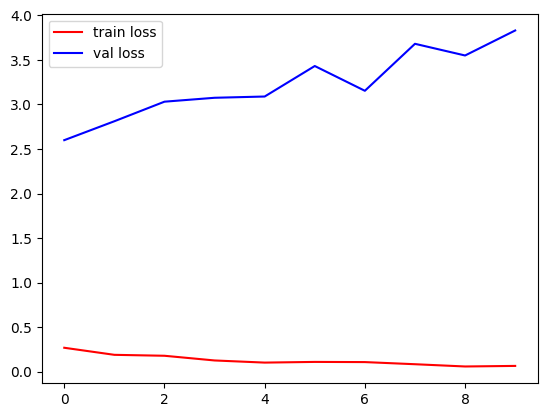

In [27]:
# It's reduce it little bit but we need to train it more...
plt.plot(history_adv.history['loss'],color='red',label='train loss')
plt.plot(history_adv.history['val_loss'],color='blue',label='val loss')
plt.legend()
plt.show()

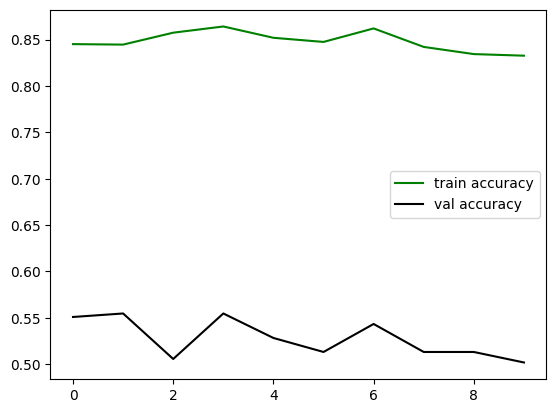

In [28]:
plt.plot(history_adv.history['accuracy'],color='green')
plt.plot(history_adv.history['val_accuracy'],color='black')
plt.legend(['train accuracy','val accuracy'])
plt.show ()


In [29]:
pred = model_adv.predict(test_ds)
y_pred_adv = np.argmax(pred, axis=1)

f1 = f1_score(y_true, y_pred_adv, average='weighted') # Use 'weighted' for multi-class classification
print(f"F1 Score: {f1:.4f}")

accuracy = accuracy_score(y_true, y_pred_adv)
print(f"Accuracy Score: {accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step
F1 Score: 0.0019
Accuracy Score: 0.0075


# Now i am going to use those pretrained model which are used in imagenet like VGG16, ResNet  with Transfer learning etc....
#1. VGG16
#2. ResNet
# In these two thier have no cards model...So we have to train atleast one hidden layer of convolution model. In the notebook named "CNN_card_detection_transfer_learning" we used PRETRAIN models

In [30]:
#Importing all the neccesary libraries and VGG16 and Resnet50 models..
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.models import Sequential
from keras.layers import Dense,Conv2D, MaxPooling2D,Flatten
import numpy as np
import matplotlib.pyplot as plt
from keras.applications.vgg16 import VGG16
from keras.applications.resnet50 import ResNet50

In [31]:
conv_base = VGG16(
    weights = 'imagenet',
    include_top = False,
    input_shape = (256,256,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [32]:
# Transfer learning with fine tuning because in the trained VGG16 or Resnet50 we don't have cards as a training images...
conv_base.trainable = True

set_trainable = False
for layer in conv_base.layers:
  if layer.name == 'block5_conv1':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

In [33]:
model_vgg = Sequential()
model_vgg.add(conv_base)
model_vgg.add(Flatten())
model_vgg.add(Dense(64,activation='relu'))
model_vgg.add(Dense(32,activation='relu'))
model_vgg.add(Dense(53,activation='softmax'))

In [34]:
model_vgg.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 8, 8, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │     2,097,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 53)             │         1,749 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,815,733 (64.15 MB)

 Trainable params: 9,180,469 (35.02 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

In [35]:
model_vgg.compile(optimizer=keras.optimizers.RMSprop(learning_rate=0.001),loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [36]:
history_vgg = model_vgg.fit(train_ds, epochs =10, validation_data = validation_ds)

Epoch 1/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 137s 421ms/step - accuracy: 0.1125 - loss: 3.8028 - val_accuracy: 0.4075 - val_loss: 2.3659
Epoch 2/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 75s 315ms/step - accuracy: 0.5661 - loss: 1.7001 - val_accuracy: 0.8226 - val_loss: 0.7384
Epoch 3/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 76s 316ms/step - accuracy: 0.7343 - loss: 1.0109 - val_accuracy: 0.8755 - val_loss: 0.4897
Epoch 4/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 76s 318ms/step - accuracy: 0.8088 - loss: 0.6949 - val_accuracy: 0.9019 - val_loss: 0.3753
Epoch 5/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 76s 318ms/step - accuracy: 0.8597 - loss: 0.5016 - val_accuracy: 0.8868 - val_loss: 0.5008
Epoch 6/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 76s 318ms/step - accuracy: 0.8837 - loss: 0.4160 - val_accuracy: 0.8717 - val_loss: 0.5314
Epoch 7/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 75s 316ms/step - accuracy: 0.9159 - loss: 0.3156 - val_accuracy: 0.8981 - val_loss: 0.6208
Epoch 8/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 76s 316ms/step - accuracy: 0.9285 - loss: 

In [37]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np


pred = model_vgg.predict(test_ds)
y_pred_vgg = np.argmax(pred, axis=1)

f1 = f1_score(y_true, y_pred_vgg, average='weighted') # Use 'weighted' for multi-class classification
print(f"F1 Score: {f1:.4f}")

accuracy = accuracy_score(y_true, y_pred_vgg)
print(f"Accuracy Score: {accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 4s 319ms/step
F1 Score: 0.0075
Accuracy Score: 0.0075


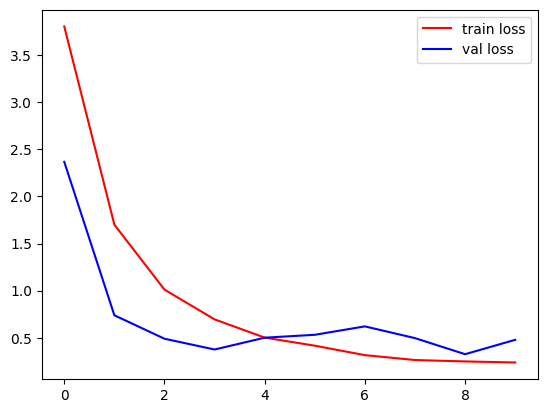

In [38]:
plt.plot(history_vgg.history['loss'],color='red',label='train loss')
plt.plot(history_vgg.history['val_loss'],color='blue',label='val loss')
plt.legend()
plt.show()

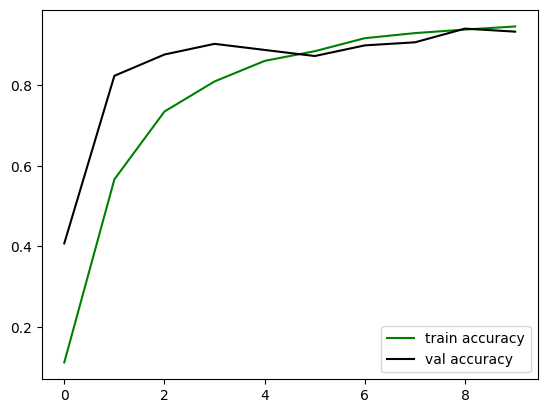

In [39]:
plt.plot(history_vgg.history['accuracy'],color='green')
plt.plot(history_vgg.history['val_accuracy'],color='black')
plt.legend(['train accuracy','val accuracy'])
plt.show ()

In [40]:
# With Resnet50 Architecture..
conv_base_resnet = keras.applications.ResNet50(
    weights = 'imagenet',
    include_top = False,
    input_shape = (256,256,3)
)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


In [41]:
conv_base_resnet.layers

[<InputLayer name=input_layer_4, built=True>,
 <ZeroPadding2D name=conv1_pad, built=True>,
 <Conv2D name=conv1_conv, built=True>,
 <BatchNormalization name=conv1_bn, built=True>,
 <Activation name=conv1_relu, built=True>,
 <ZeroPadding2D name=pool1_pad, built=True>,
 <MaxPooling2D name=pool1_pool, built=True>,
 <Conv2D name=conv2_block1_1_conv, built=True>,
 <BatchNormalization name=conv2_block1_1_bn, built=True>,
 <Activation name=conv2_block1_1_relu, built=True>,
 <Conv2D name=conv2_block1_2_conv, built=True>,
 <BatchNormalization name=conv2_block1_2_bn, built=True>,
 <Activation name=conv2_block1_2_relu, built=True>,
 <Conv2D name=conv2_block1_0_conv, built=True>,
 <Conv2D name=conv2_block1_3_conv, built=True>,
 <BatchNormalization name=conv2_block1_0_bn, built=True>,
 <BatchNormalization name=conv2_block1_3_bn, built=True>,
 <Add name=conv2_block1_add, built=True>,
 <Activation name=conv2_block1_out, built=True>,
 <Conv2D name=conv2_block2_1_conv, built=True>,
 <BatchNormalization 

In [44]:
conv_base_resnet.trainable = True

set_trainable = False
for layer in conv_base_resnet.layers:
  if layer.name == 'conv5_block1_out':
    set_trainable = True
  if set_trainable:
    layer.trainable = True
  else:
    layer.trainable = False

In [45]:
model_resnet  = Sequential()

model_resnet.add(conv_base_resnet)
model_resnet.add(Flatten())
model_resnet.add(Dense(64,activation='relu'))
model_resnet.add(Dense(32,activation='relu'))
model_resnet.add(Dense(53,activation='sigmoid'))

In [46]:
model_resnet.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [47]:
history_resnet = model_resnet.fit(train_ds, epochs =10, validation_data = validation_ds)

Epoch 1/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 92s 254ms/step - accuracy: 0.0192 - loss: 4.0394 - val_accuracy: 0.0189 - val_loss: 3.9705
Epoch 2/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 39s 163ms/step - accuracy: 0.0237 - loss: 3.9680 - val_accuracy: 0.0189 - val_loss: 3.9709
Epoch 3/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 37s 152ms/step - accuracy: 0.0237 - loss: 3.9667 - val_accuracy: 0.0189 - val_loss: 3.9715
Epoch 4/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 36s 152ms/step - accuracy: 0.0237 - loss: 3.9657 - val_accuracy: 0.0189 - val_loss: 3.9722
Epoch 5/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 41s 153ms/step - accuracy: 0.0237 - loss: 3.9651 - val_accuracy: 0.0189 - val_loss: 3.9729
Epoch 6/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 36s 151ms/step - accuracy: 0.0237 - loss: 3.9646 - val_accuracy: 0.0189 - val_loss: 3.9735
Epoch 7/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 36s 151ms/step - accuracy: 0.0237 - loss: 3.9643 - val_accuracy: 0.0189 - val_loss: 3.9741
Epoch 8/10
239/239 ━━━━━━━━━━━━━━━━━━━━ 38s 157ms/step - accuracy: 0.0237 - loss: 3

In [48]:
from sklearn.metrics import f1_score, accuracy_score
import numpy as np


pred = model_resnet.predict(test_ds)
y_pred_resnet= np.argmax(pred, axis=1)

f1 = f1_score(y_true, y_pred_resnet, average='weighted') # Use 'weighted' for multi-class classification
print(f"F1 Score: {f1:.4f}")

accuracy = accuracy_score(y_true, y_pred_resnet)
print(f"Accuracy Score: {accuracy:.4f}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 9s 614ms/step
F1 Score: 0.0007
Accuracy Score: 0.0189


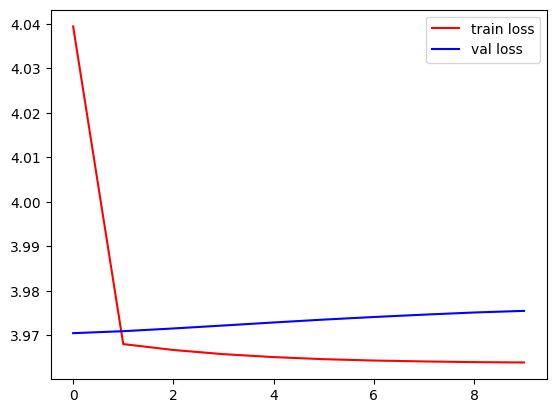

In [49]:
plt.plot(history_resnet.history['loss'],color='red',label='train loss')
plt.plot(history_resnet.history['val_loss'],color='blue',label='val loss')
plt.legend()
plt.show()

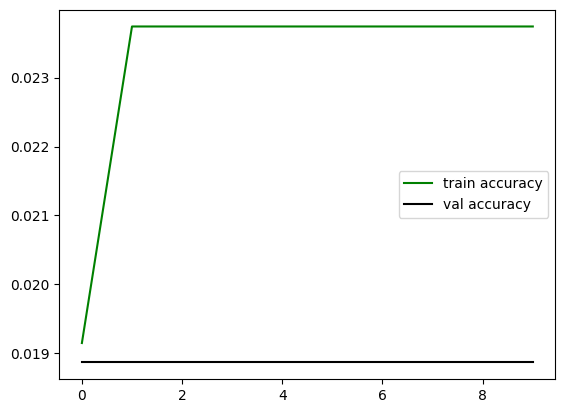

In [50]:
plt.plot(history_resnet.history['accuracy'],color='green')
plt.plot(history_resnet.history['val_accuracy'],color='black')
plt.legend(['train accuracy','val accuracy'])
plt.show ()

# **Conclusion**: Over the card classification DataSet The VGGNET architecture acts relly well and out architecture and reset are not predict very well. So in that project of Card Detection VGGNET performs better than RESNET , We train the model till 10 epochs only , it will work very well if we  train our model in a large epochs.